In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from utils.pde import PDE
from utils.triangulation import Triangulation
from utils.finite_element import LagrangeBasis, FiniteElement
from utils.tensor_network import TensorUnit, TensorNetwork
from utils.solver import DMRG

In [2]:
r = [0, 0.01]

In [3]:
def avg_diff(y_real, y_pred):
    return np.mean(np.abs(y_real - y_pred))

In [4]:
step = 100

x = np.linspace(0, 1, step)
x_step = 1/step
y0 = np.exp(-100 * (x - 0.5) ** 2) + np.exp(-100 * (x + 0.5) ** 2) + np.exp(-100 * (x - 1.5) ** 2)


def d2(u):
    u = np.concatenate([np.array(u[:1]), u,np.array(u[-1:])])
    return (u[2:] + u[:-2] + -2*u[1:-1])/x_step ** 2

def dxdxu(t, u):
    return d2(u)

y = solve_ivp(dxdxu, r, y0, t_eval = np.array(r[-1:]))

In [5]:
Ns = [2, 4, 6, 8, 10]
deltas = [0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001]
steps = [int(r[-1]/delta) for delta in deltas]

In [6]:
pde_dxdxu_txt = 'D[2, 0, 0]'
pde_dxdxu = PDE(pde_dxdxu_txt, equal_time_derivative = True)

continuity_order = 1
bond_order = 1
rounds = 10
alpha = 1

In [7]:
out = []

basis_order = 2
for elements in Ns:
    print(elements)
    out_delta = []
    for delta, n_steps in zip(deltas, steps):
        print('\t'+ str(delta))
        triangulation = Triangulation(np.linspace(0, 1, elements + 1))
        basis = LagrangeBasis(1, basis_order)

        fe = FiniteElement(triangulation, basis)
        fe.set_con_bc_operators(continuity_order)
        fe.set_env_bc_operators({0: {1: ([np.array([[0]]), np.array([[[1]]])], 
                                        np.array([[0]]))},
                                elements - 1: {0: ([np.array([[0]]), np.array([[[1]]])], 
                                        np.array([[0]]))}})

        fe.calculate_higher_domain_derivatives(2)

        tn = TensorNetwork(basis.rank, triangulation.neighbors, fe.domain_derivatives_list, basis.tp_reduce)
        tn.set_u_shape(tuple())
        tn.set_h_tensor_units([])

        y0 = lambda x: np.exp(-100 * (x - 0.5) ** 2) + np.exp(-100 * (x + 0.5) ** 2) + np.exp(-100 * (x - 1.5) ** 2)
        rep = fe.fun2rep(y0)
        rep = np.broadcast_to(rep[..., None, None], rep.shape + (bond_order,) * (basis.d + 1))
        states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

        all_reps = [[states.tensor[..., 0, 0].copy()]]
        for reps, pde in zip(all_reps, [pde_dxdxu]):
            for i in range(int(n_steps)):
                pde_operators, pde_power =  tn.get_operators_from_pde(pde.pde, delta, states.copy())
                tn.set_states(states, bond_order)
                tn.set_bcs(fe.con_bc_operators, fe.env_bc_operators, 1)
                tn.set_solver(DMRG())
                tn.set_operators(pde_operators, pde_power)
                states = tn.solve(rounds = rounds, alpha = alpha, env = True)
                reps.append(states.tensor[..., 0, 0].copy())
            states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

        out_delta.append(avg_diff(fe.rep2fun(all_reps[-1][-1])(x), y.y[..., -1]))
    out.append(out_delta)


2
	0.01
	0.005
	0.002
	0.001
	0.0005
	0.0002
	0.0001
4
	0.01
	0.005
	0.002
	0.001
	0.0005
	0.0002
	0.0001
6
	0.01
	0.005
	0.002
	0.001
	0.0005
	0.0002
	0.0001
8
	0.01
	0.005
	0.002
	0.001
	0.0005
	0.0002
	0.0001
10
	0.01
	0.005
	0.002
	0.001
	0.0005
	0.0002
	0.0001


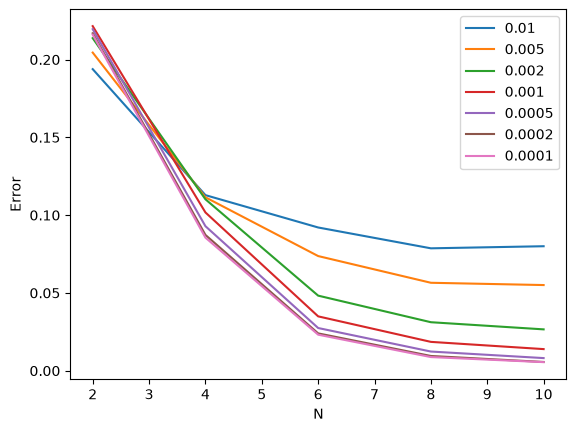

In [8]:
out = np.array(out).T
for o, delta in zip(out, deltas):
    plt.plot(Ns, o, label = f'{delta}')

plt.xlabel('N')
plt.ylabel('Error')
plt.legend()
plt.show()

In [12]:
tmp = np.array([[0.19384667, 0.11285691, 0.09206282, 0.07867108, 0.08001384],
       [0.20448309, 0.11146949, 0.07369322, 0.05652242, 0.05505721],
       [0.21375863, 0.11018996, 0.04825074, 0.03116911, 0.02657293],
       [0.22148404, 0.10172779, 0.03493405, 0.01853554, 0.01388503],
       [0.21953901, 0.09289424, 0.02743651, 0.01232043, 0.0081106 ],
       [0.21689923, 0.0872841 , 0.02398551, 0.00947169, 0.00561944],
       [0.21601062, 0.08553034, 0.02315589, 0.00876352, 0.00550492]])

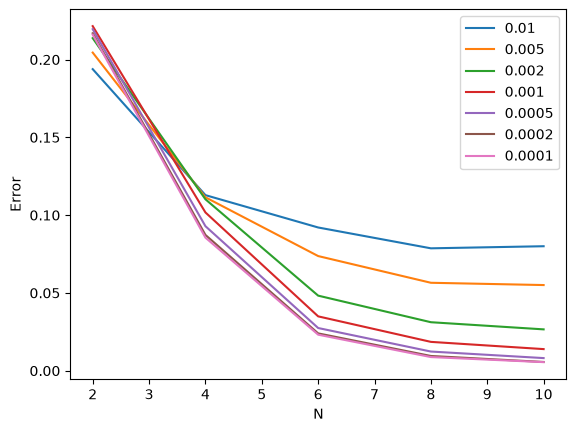

In [13]:
for o, delta in zip(tmp, deltas):
    plt.plot(Ns, o, label = f'{delta}')

plt.xlabel('N')
plt.ylabel('Error')
plt.legend()
plt.show()